In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path("../raw_data")

files = sorted(data_dir.glob("CRMLSSold*.csv"))

print("Looking in:", data_dir.resolve())
print("Number of files found:", len(files))
files

Looking in: /Users/karthikx06/Documents/IDX_Exchange/data/raw_data
Number of files found: 7


[PosixPath('../raw_data/CRMLSSold202511.csv'),
 PosixPath('../raw_data/CRMLSSold202512.csv'),
 PosixPath('../raw_data/CRMLSSold202601.csv'),
 PosixPath('../raw_data/CRMLSSold202602.csv'),
 PosixPath('../raw_data/CRMLSSold202603.csv'),
 PosixPath('../raw_data/CRMLSSold202604.csv'),
 PosixPath('../raw_data/CRMLSSold202605.csv')]

In [3]:
dfs = []

for file in files:
    df_month = pd.read_csv(file, low_memory=False)
    df_month["source_file"] = file.name
    dfs.append(df_month)

df = pd.concat(dfs, ignore_index=True)

df.shape

(143492, 79)

In [4]:
# See what's actually in there first
print(df["PropertyType"].value_counts(dropna=False))
print(df["PropertySubType"].value_counts(dropna=False))

sfr = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(sfr.shape)

PropertyType
Residential            95621
ResidentialLease       33973
Land                    4599
ResidentialIncome       3923
ManufacturedInPark      3673
CommercialSale           912
CommercialLease          714
BusinessOpportunity       77
Name: count, dtype: int64
PropertySubType
SingleFamilyResidence    87064
Condominium              24899
NaN                      10507
Townhouse                 8375
Apartment                 3902
Duplex                    2901
ManufacturedOnLand        1411
Triplex                    980
Quadruplex                 924
MixedUse                   530
StockCooperative           451
Office                     381
Retail                     226
Industrial                 160
Cabin                      131
Studio                     115
Business                   101
RoomingHouse                96
Warehouse                   76
MultiFamily                 37
SpecialPurpose              35
MobileHome                  35
BoatSlip                    34


nulls: 0
zeros/negatives: 0


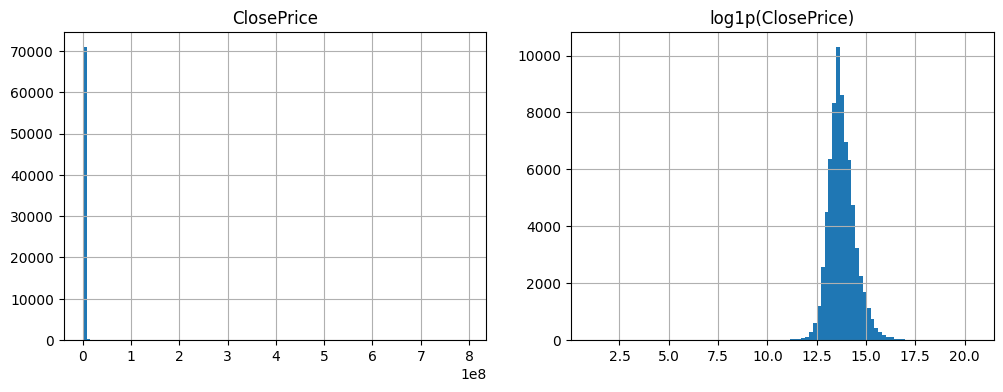

In [5]:
sfr["ClosePrice"].describe()
print("nulls:", sfr["ClosePrice"].isna().sum())
print("zeros/negatives:", (sfr["ClosePrice"] <= 0).sum())

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sfr["ClosePrice"].hist(bins=100, ax=ax[0]); ax[0].set_title("ClosePrice")
np.log1p(sfr["ClosePrice"]).hist(bins=100, ax=ax[1]); ax[1].set_title("log1p(ClosePrice)")
plt.show()

In [6]:
sfr["ClosePrice"].quantile([0.001, 0.01, 0.5, 0.99, 0.999])

0.001       85000.0
0.010      230000.0
0.500      889000.0
0.990     6500000.0
0.999    18069550.0
Name: ClosePrice, dtype: float64

In [7]:
miss = sfr.isna().mean().sort_values(ascending=False)
miss[miss > 0].head(40)

CoveredSpaces                   1.000000
MiddleOrJuniorSchoolDistrict    1.000000
TaxYear                         1.000000
ElementarySchoolDistrict        1.000000
BusinessType                    1.000000
TaxAnnualAmount                 1.000000
FireplacesTotal                 1.000000
AboveGradeFinishedArea          1.000000
WaterfrontYN                    0.999482
BelowGradeFinishedArea          0.992752
BasementYN                      0.976031
BuilderName                     0.954426
LotSizeDimensions               0.937621
BuildingAreaTotal               0.933101
CoBuyerAgentFirstName           0.906011
ElementarySchool                0.872835
MiddleOrJuniorSchool            0.872303
HighSchool                      0.832102
CoListAgentFirstName            0.766420
CoListAgentLastName             0.765609
CoListOfficeName                0.765553
AssociationFeeFrequency         0.739694
SubdivisionName                 0.646391
MainLevelBedrooms               0.389570
Flooring        

In [8]:
sfr.isna()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_file
0,False,False,False,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,True,True,True,True,False,False,...,False,True,False,False,False,False,True,False,True,False
2,False,False,True,False,True,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,False,False,True,False,True,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4,False,False,True,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143458,False,False,True,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
143460,True,False,False,False,True,True,False,False,False,False,...,False,True,False,False,True,False,True,False,True,False
143468,False,False,False,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
143470,False,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False


In [9]:
core = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
        "LotSizeSquareFeet", "YearBuilt"]
sfr[core].describe()

,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt
count,71432.000000,71466.000000,71465.000000,7.023900e+04,71425.000000
mean,2053.831846,3.497397,2.641503,4.813743e+05,1976.202506
std,1038.535401,0.967289,1.132245,2.122478e+07,27.716933
min,0.000000,0.000000,0.000000,0.000000e+00,1801.000000
25%,1387.000000,3.000000,2.000000,5.663000e+03,1956.000000
50%,1824.000000,3.000000,2.000000,7.260000e+03,1977.000000
75%,2451.000000,4.000000,3.000000,1.045400e+04,1999.000000
max,31068.000000,22.000000,23.000000,1.938943e+09,2026.000000


In [10]:
sfr["CloseDate"] = pd.to_datetime(sfr["CloseDate"], errors="coerce")
print(sfr["CloseDate"].min(), "→", sfr["CloseDate"].max())
print("coords missing:", sfr[["Latitude", "Longitude"]].isna().any(axis=1).sum())

2025-11-01 00:00:00 → 2026-05-31 00:00:00
coords missing: 9


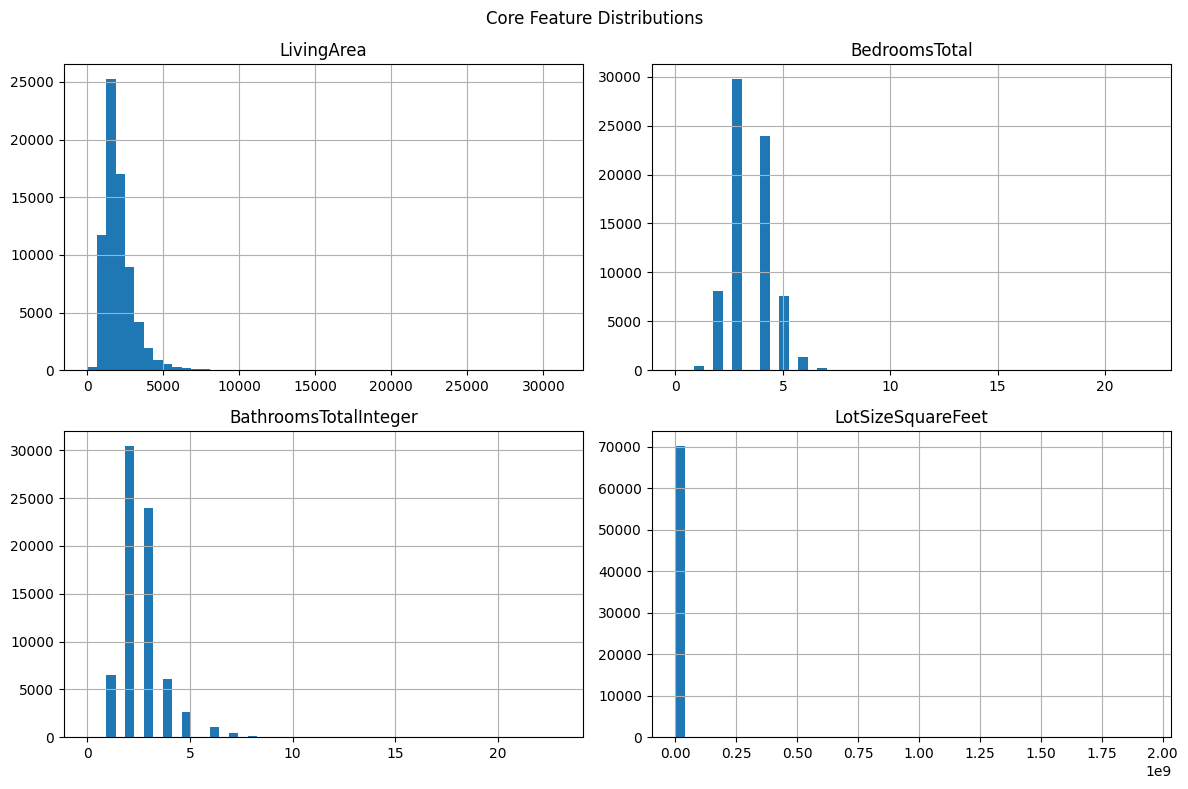

In [11]:
sfr[["LivingArea", "BedroomsTotal", 
     "BathroomsTotalInteger", "LotSizeSquareFeet"]].hist(
    bins=50, figsize=(12, 8)
)
plt.suptitle("Core Feature Distributions")
plt.tight_layout()
plt.show()

In [15]:
import os
os.makedirs('data/processed', exist_ok=True)

sfr.to_csv('data/processed/week2_filtered.csv', index=False)